In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q gdown

In [3]:
!gdown --id 14K-mX-Aqqk8cNdTmZHEmMVf7y4wtuSxJ --output animals10.zip

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=14K-mX-Aqqk8cNdTmZHEmMVf7y4wtuSxJ
From (redirected): https://drive.google.com/uc?id=14K-mX-Aqqk8cNdTmZHEmMVf7y4wtuSxJ&confirm=t&uuid=307171c6-8133-4ddf-ab8c-64cf9102b6d9
To: /content/animals10.zip
100% 614M/614M [00:11<00:00, 55.4MB/s]


In [8]:
!unzip -q animals10.zip -d ./animals10

In [7]:
# import shutil
# import os

# root_dir = '/content/animals10/'

# for item in os.listdir(root_dir):
#     item_path = os.path.join(root_dir, item)

#     try:
#         if os.path.isfile(item_path) or os.path.islink(item_path):
#             os.unlink(item_path)
#         elif os.path.isdir(item_path):
#             shutil.rmtree(item_path)
#     except Exception as e:
#         print(f"Помилка при видаленні {item_path}: {e}")


In [9]:
data_dir = './animals10/raw-img'

translate = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}

In [10]:
import os

for italian, english in translate.items():
    src = os.path.join(data_dir, italian)
    dst = os.path.join(data_dir, english)

    if os.path.exists(src):
        os.rename(src, dst)

In [11]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


data = datasets.ImageFolder(data_dir, transform=transform)

In [12]:
print(f"Кількість класів: {len(data.classes)}")

Кількість класів: 10


In [13]:
print(f"Класи: {data.classes}")

Класи: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


In [14]:
import numpy as np
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

labels = np.array(data.targets)

train_val_idx, test_idx = train_test_split(
    np.arange(len(data)), test_size=0.2, random_state=42, shuffle=True, stratify=labels
)

train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.25, random_state=42, shuffle=True, stratify=labels[train_val_idx]
)

train_data = Subset(data, train_idx)
val_data = Subset(data, val_idx)
test_data = Subset(data, test_idx)

In [15]:
print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

Train size: 15707
Validation size: 5236
Test size: 5236


Структура папок:

У кореневій директорії animals10/raw-img/ 10 підпапок із назвами тварин англійською (dog, cat, elephant, тощо), кожна з них містить зображення, що належать відповідному класу.

In [16]:
from PIL import Image

dog_path = './animals10/raw-img/dog'
dog_file = os.listdir('./animals10/raw-img/dog')[0]

img_path = os.path.join(dog_path, dog_file)

img = Image.open(img_path)

print(f"Файл: {img_path}")
print(f"Формат: {img.format}")
print(f"Розмір: {img.size}")
print(f"Режим: {img.mode}")

Файл: ./animals10/raw-img/dog/OIP-Sps29w0B-PokV_K1SBIa6gHaFj.jpeg
Формат: JPEG
Розмір: (300, 225)
Режим: RGB


In [29]:
from torch.utils.data import DataLoader

batch_size = 32
num_workers = 0

train_loader = DataLoader(
    train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers
)

val_loader = DataLoader(
    val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

test_loader = DataLoader(
    test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

In [30]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [31]:
train_loader.dataset.transform = train_transform
val_loader.dataset.transform = val_test_transform
test_loader.dataset.transform = val_test_transform

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import laplace
from skimage.measure import shannon_entropy

def analyze_noise(img_tensor):
    img = img_tensor.numpy().transpose(1, 2, 0)
    gray = np.mean(img, axis=2)
    sharpness = laplace(gray).var()
    entropy = shannon_entropy(gray)
    return sharpness, entropy

def process_and_plot(loader, loader_name, max_images=500):
    sharpness_list = []
    entropy_list = []

    count = 0
    for images, labels in loader:
        for img in images:
            sharpness, entropy = analyze_noise(img.cpu())
            sharpness_list.append(sharpness)
            entropy_list.append(entropy)
            count += 1
            if count >= max_images:
                break
        if count >= max_images:
            break

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(sharpness_list, bins=30, alpha=0.7)
    axes[0].set_title(f'{loader_name} — Розподіл різкості')
    axes[0].set_xlabel('Sharpness')
    axes[0].set_ylabel('Кількість зображень')

    axes[1].hist(entropy_list, bins=30, alpha=0.7, color='orange')
    axes[1].set_title(f'{loader_name} — Розподіл ентропії')
    axes[1].set_xlabel('Entropy')
    axes[1].set_ylabel('Кількість зображень')

    plt.suptitle(f"Аналіз показників шуму — {loader_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

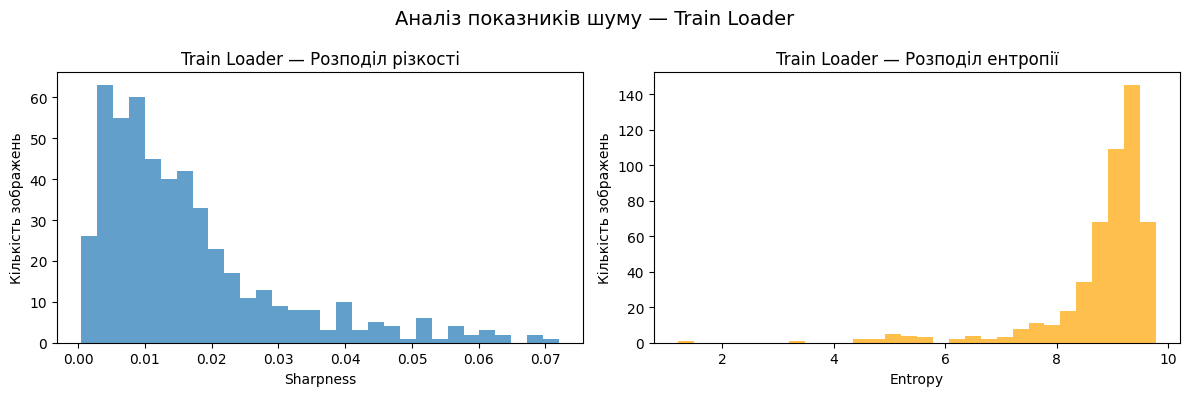

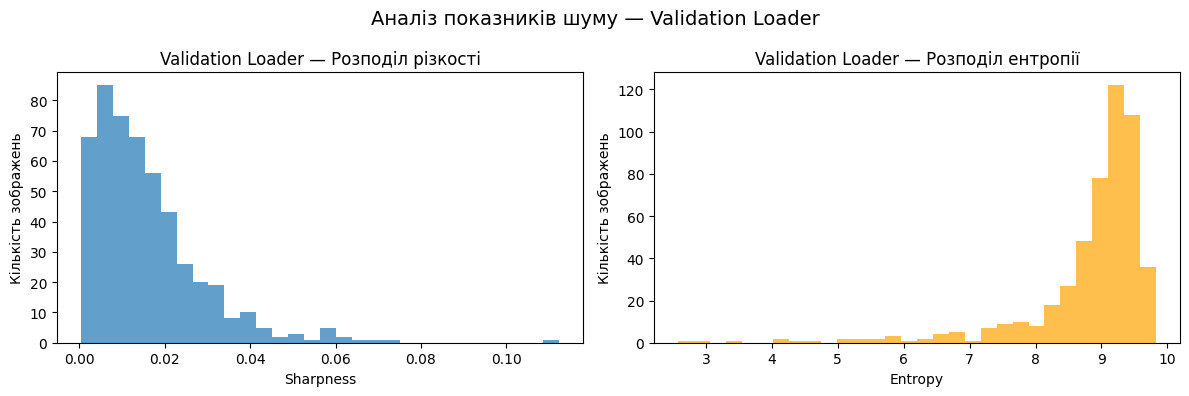

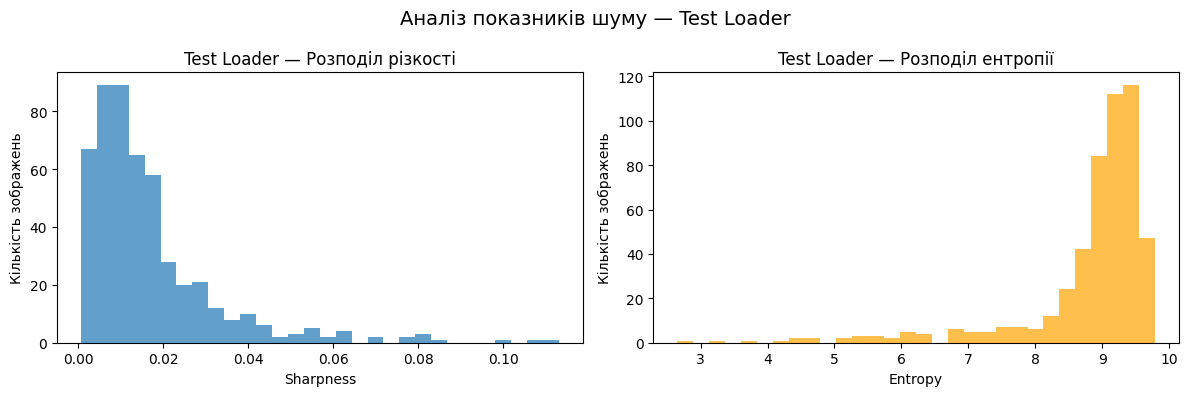

In [34]:
process_and_plot(train_loader, "Train Loader")
process_and_plot(val_loader, "Validation Loader")
process_and_plot(test_loader, "Test Loader")

Усі набори мають подібний розподіл: більшість зображень демонструють низьку різкість та високу ентропію, що є типовим для якісних природних зображень. Зашумлені приклади зустрічаються поодиноко, переважно в тренувальному та тестовому наборах, але не становлять загрози для якості моделі.

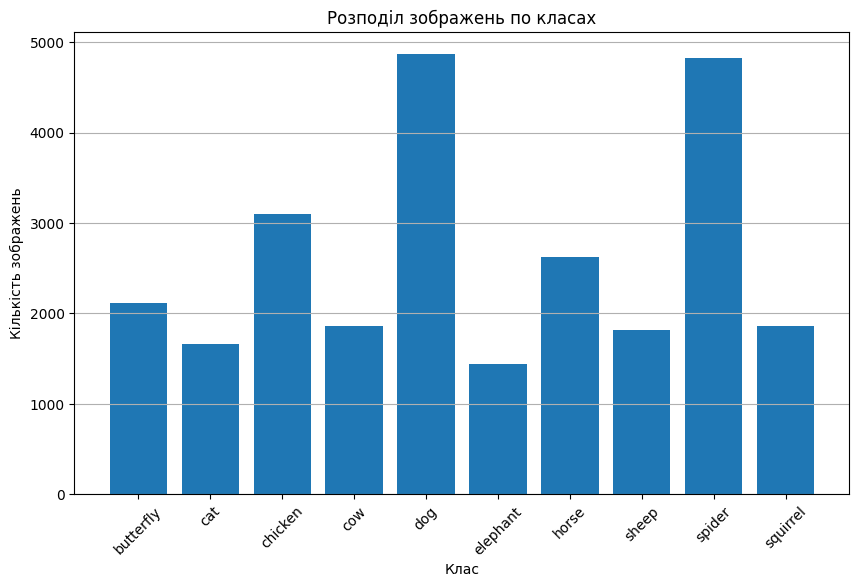

In [20]:
import matplotlib.pyplot as plt
from collections import Counter

class_counts = Counter(labels)

idx_to_class = {v: k for k, v in data.class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]

plt.figure(figsize=(10, 6))
plt.bar(class_names, counts)
plt.title('Розподіл зображень по класах')
plt.xlabel('Клас')
plt.ylabel('Кількість зображень')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

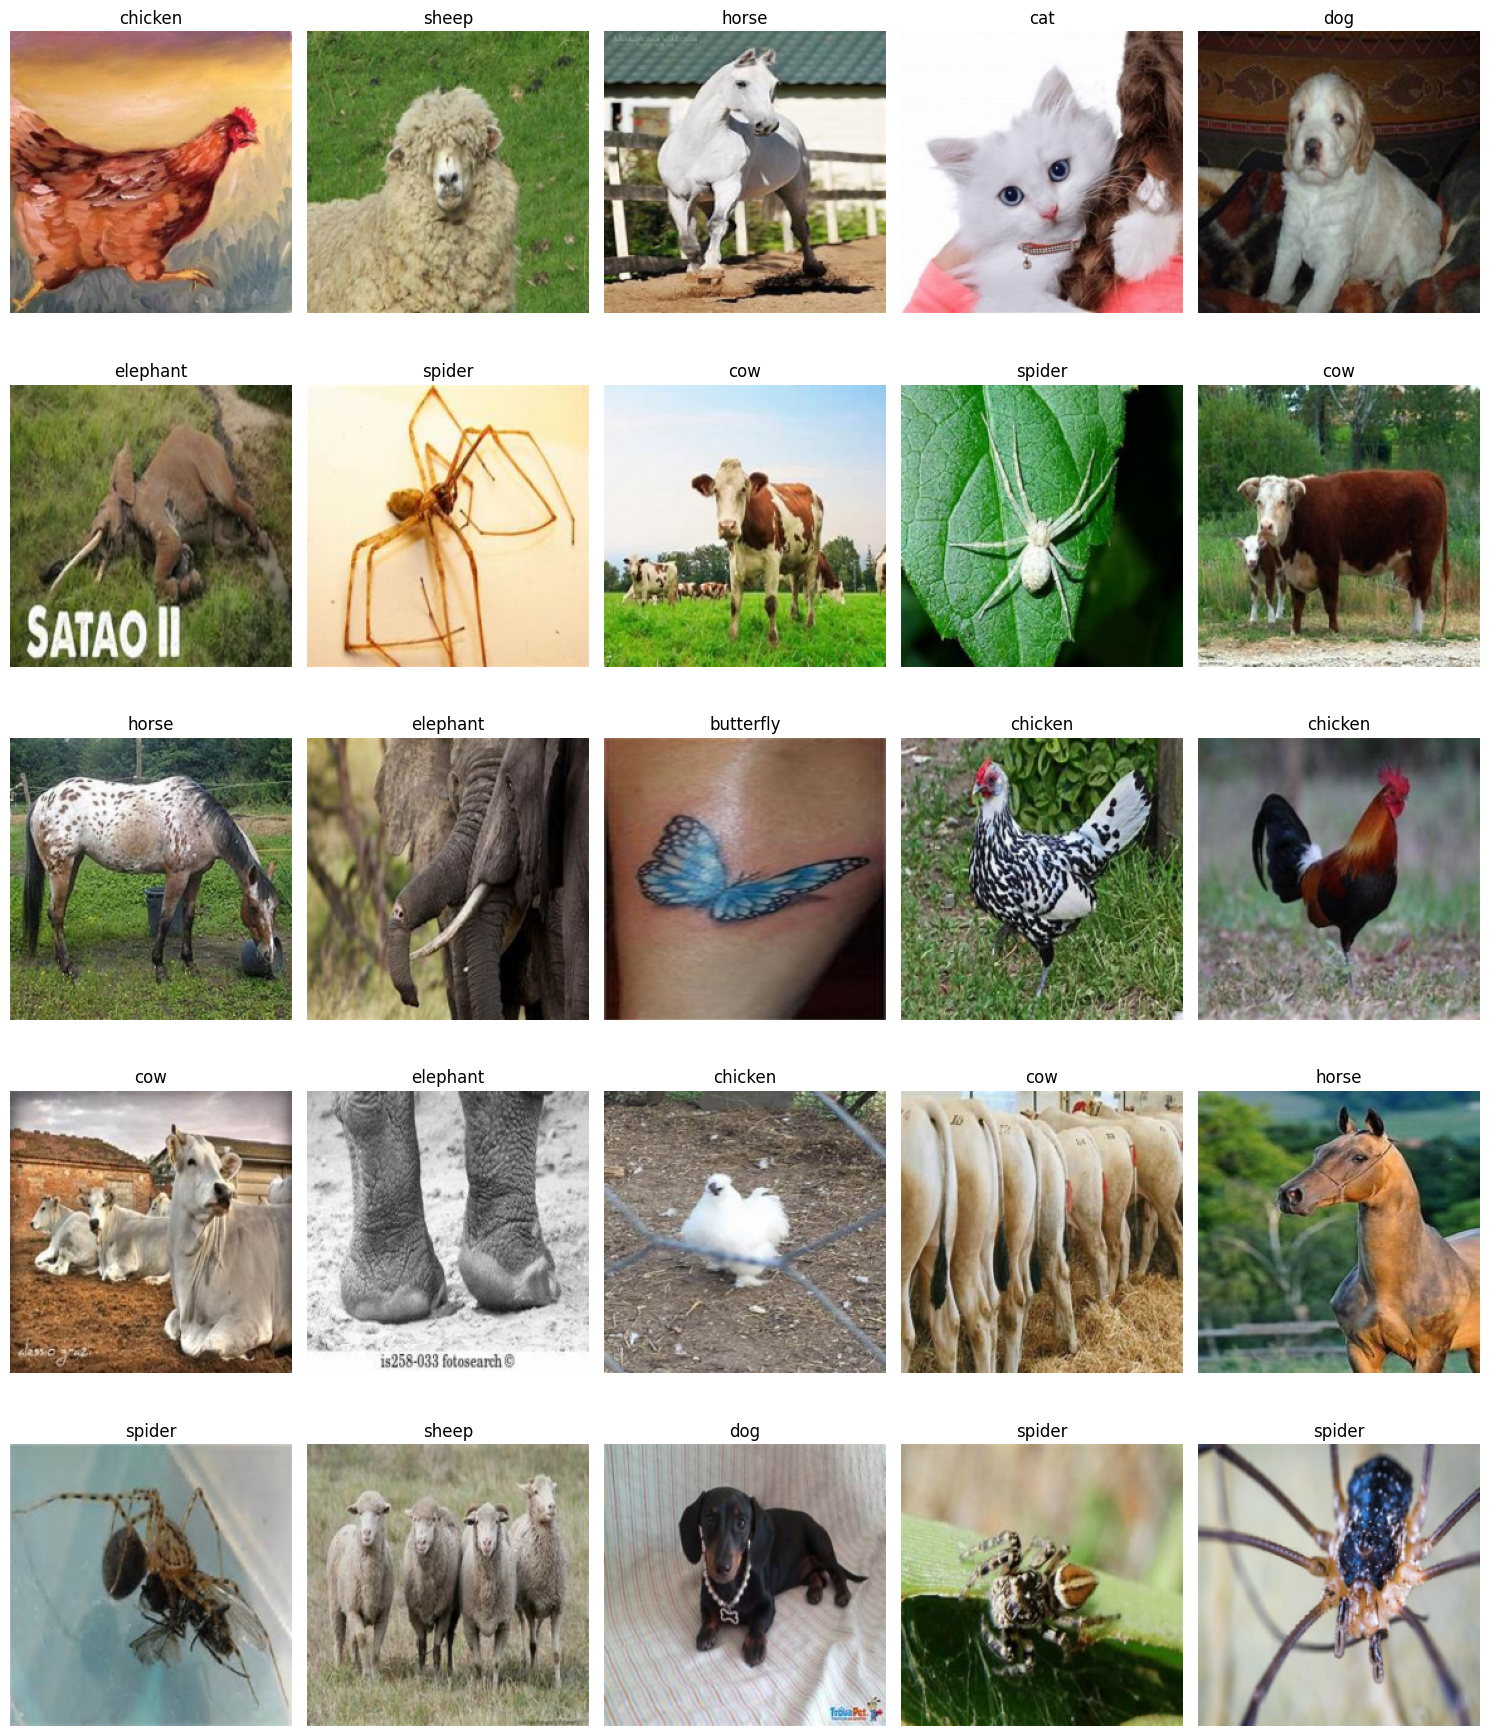

In [21]:
fig, axes = plt.subplots(5, 5, figsize=(15, 18))
axes = axes.flatten()

for i, ax in enumerate(axes):
    idx = np.random.randint(0, len(data))
    img_tensor, label = data[idx]
    ax.imshow(np.transpose(img_tensor.numpy(), (1, 2, 0)))
    ax.set_title(f"{idx_to_class[label]}")
    ax.axis('off')

plt.tight_layout()
plt.show()
